# Challenge 02: Logistic regression

## Objective

The goal is to classify each vibration signal as `0` (undamaged) or `1` (damaged), following the description in `README.md`.
The notebook follows the same staged style as the reference activities:

1. Load the data and understand the problem.
2. Audit data quality.
3. Explore patterns visually.
4. Split data into training and validation subsets.
5. Train and tune one model from the course material.
6. Evaluate the model using accuracy and a confusion matrix.
7. Interpret the model and export a Kaggle-style submission.

All figures generated by this notebook are saved to an individual folder under `challenge/output/`.

## 0. Load libraries

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["savefig.bbox"] = "tight"

RANDOM_STATE = 301655

## 1. Configure the model-specific experiment

In [2]:
from sklearn.linear_model import LogisticRegression

MODEL_NAME = "Logistic regression"
NOTEBOOK_SLUG = "challenge_02_logistic_regression"
CV_FOLDS = 5

MODEL_PIPELINE = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=4000, random_state=RANDOM_STATE)),
    ]
)

PARAM_GRID = {
    "model__C": [0.01, 0.1, 1.0, 10.0],
    "model__solver": ["lbfgs"],
}

## 2. Load the challenge data

In [3]:
BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR / "data" / "training.csv"
TEST_PATH = BASE_DIR / "data" / "test.csv"
SAMPLE_PATH = BASE_DIR / "data" / "sample.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_df = pd.read_csv(SAMPLE_PATH)

X = train_df.drop(columns=["id", "class"])
y = train_df["class"]
X_test_kaggle = test_df.drop(columns=["id"])

TEST_SIZE = 0.20

output_dir = BASE_DIR / "output" / NOTEBOOK_SLUG
output_dir.mkdir(parents=True, exist_ok=True)

submission_dir = BASE_DIR / "submissions"
submission_dir.mkdir(parents=True, exist_ok=True)

def save_current_figure(filename: str) -> Path:
    path = output_dir / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    return path

def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict:
    cm = confusion_matrix(y_true, y_pred)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "confusion_matrix": cm.tolist(),
    }

## 3. First look at the training data

In [4]:
train_df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V192,V193,V194,V195,V196,V197,V198,V199,V200,class
0,1,-0.057380,-0.034320,0.108180,0.339966,0.260549,0.157619,0.180302,0.013498,0.057710,...,-0.667542,-0.305585,-0.272317,-0.246890,0.233585,0.405540,0.171378,0.312641,0.276437,0
1,2,0.158580,-0.040992,-0.223969,-0.202901,-0.172670,-0.367184,-0.197889,0.277498,0.141608,...,-0.565112,-0.090816,-0.137104,-0.135052,-0.551614,-0.061946,0.254908,0.443442,0.072714,1
2,3,0.192731,0.092100,-0.408607,-0.424280,-0.299382,0.097473,0.082899,-0.268221,-0.438407,...,0.081077,0.187997,0.363433,0.285123,0.037218,-0.247144,-0.166505,-0.234500,-0.467270,1
3,4,0.531353,0.417531,0.551215,0.592737,0.301150,-0.193523,-0.618740,-0.317652,-0.429237,...,0.198765,0.078372,0.146174,-0.261510,-0.291864,-0.308821,-0.476409,-0.173238,0.029824,1
4,5,0.262440,0.423357,0.250080,0.123822,0.230403,0.407454,0.036488,-0.207874,-0.393434,...,0.481552,0.413519,0.286791,0.132123,0.118849,0.002060,-0.453681,-0.838059,-0.626842,1


## 4. Check shape, target balance, and data types

In [5]:
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_df.shape)
print("\nTarget distribution:")
display(train_df["class"].value_counts().sort_index())
print("\nDtypes summary:")
display(train_df.dtypes.value_counts())

Training shape: (10000, 202)
Test shape: (3000, 201)
Sample submission shape: (3000, 2)

Target distribution:


class
0    5000
1    5000
Name: count, dtype: int64


Dtypes summary:


float64    200
int64        2
Name: count, dtype: int64

## 5. Data quality audit

In [6]:
quality_report = pd.DataFrame(
    {
        "missing_values": train_df.isna().sum(),
        "missing_pct": train_df.isna().mean().mul(100),
        "n_unique": train_df.nunique(),
    }
)

print("Duplicate rows in training:", int(train_df.duplicated().sum()))
print("Duplicated ids in training:", int(train_df["id"].duplicated().sum()))
print("Duplicated ids in test:", int(test_df["id"].duplicated().sum()))
print("Total missing values in training:", int(train_df.isna().sum().sum()))
print("Total missing values in test:", int(test_df.isna().sum().sum()))
quality_report.head(10)

Duplicate rows in training: 0
Duplicated ids in training: 0
Duplicated ids in test: 0
Total missing values in training: 0
Total missing values in test: 0


,missing_values,missing_pct,n_unique
id,0,0.0,10000
V1,0,0.0,9795
V2,0,0.0,9808
V3,0,0.0,9782
V4,0,0.0,9807
V5,0,0.0,9801
V6,0,0.0,9783
V7,0,0.0,9818
V8,0,0.0,9829
V9,0,0.0,9793


## 6. Plot the class balance

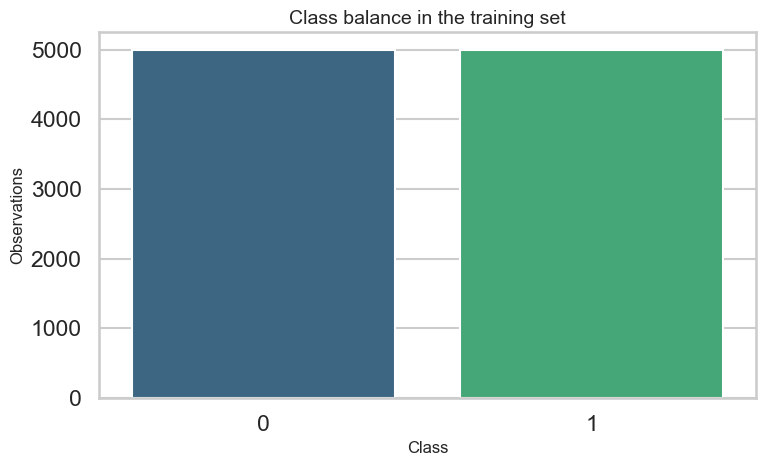

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/class_balance.png


In [7]:
class_counts = train_df["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette="viridis")
plt.title("Class balance in the training set")
plt.xlabel("Class")
plt.ylabel("Observations")
class_balance_path = save_current_figure("class_balance.png")
plt.show()

print(f"Saved figure: {class_balance_path}")

## 7. Identify features with the largest mean separation between classes

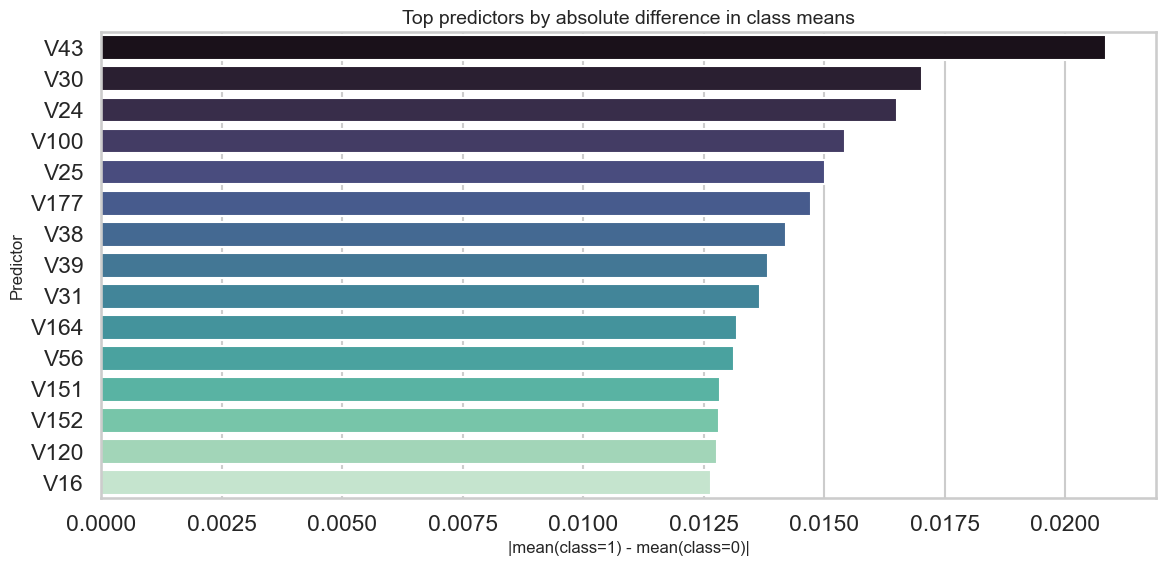

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/top_mean_gaps.png


,absolute_mean_gap
V43,0.020844
V30,0.017038
V24,0.016515
V100,0.015431
V25,0.015020
V177,0.014728
V38,0.014202
V39,0.013829
V31,0.013671
V164,0.013196


In [8]:
feature_mean_gap = (
    train_df.groupby("class")
    .mean(numeric_only=True)
    .drop(columns=["id"])
    .diff()
    .iloc[-1]
    .abs()
    .sort_values(ascending=False)
)

top_gap_features = feature_mean_gap.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_gap_features.values, y=top_gap_features.index, palette="mako")
plt.title("Top predictors by absolute difference in class means")
plt.xlabel("|mean(class=1) - mean(class=0)|")
plt.ylabel("Predictor")
gap_path = save_current_figure("top_mean_gaps.png")
plt.show()

print(f"Saved figure: {gap_path}")
display(top_gap_features.to_frame("absolute_mean_gap"))

## 8. Inspect the six most separated predictors

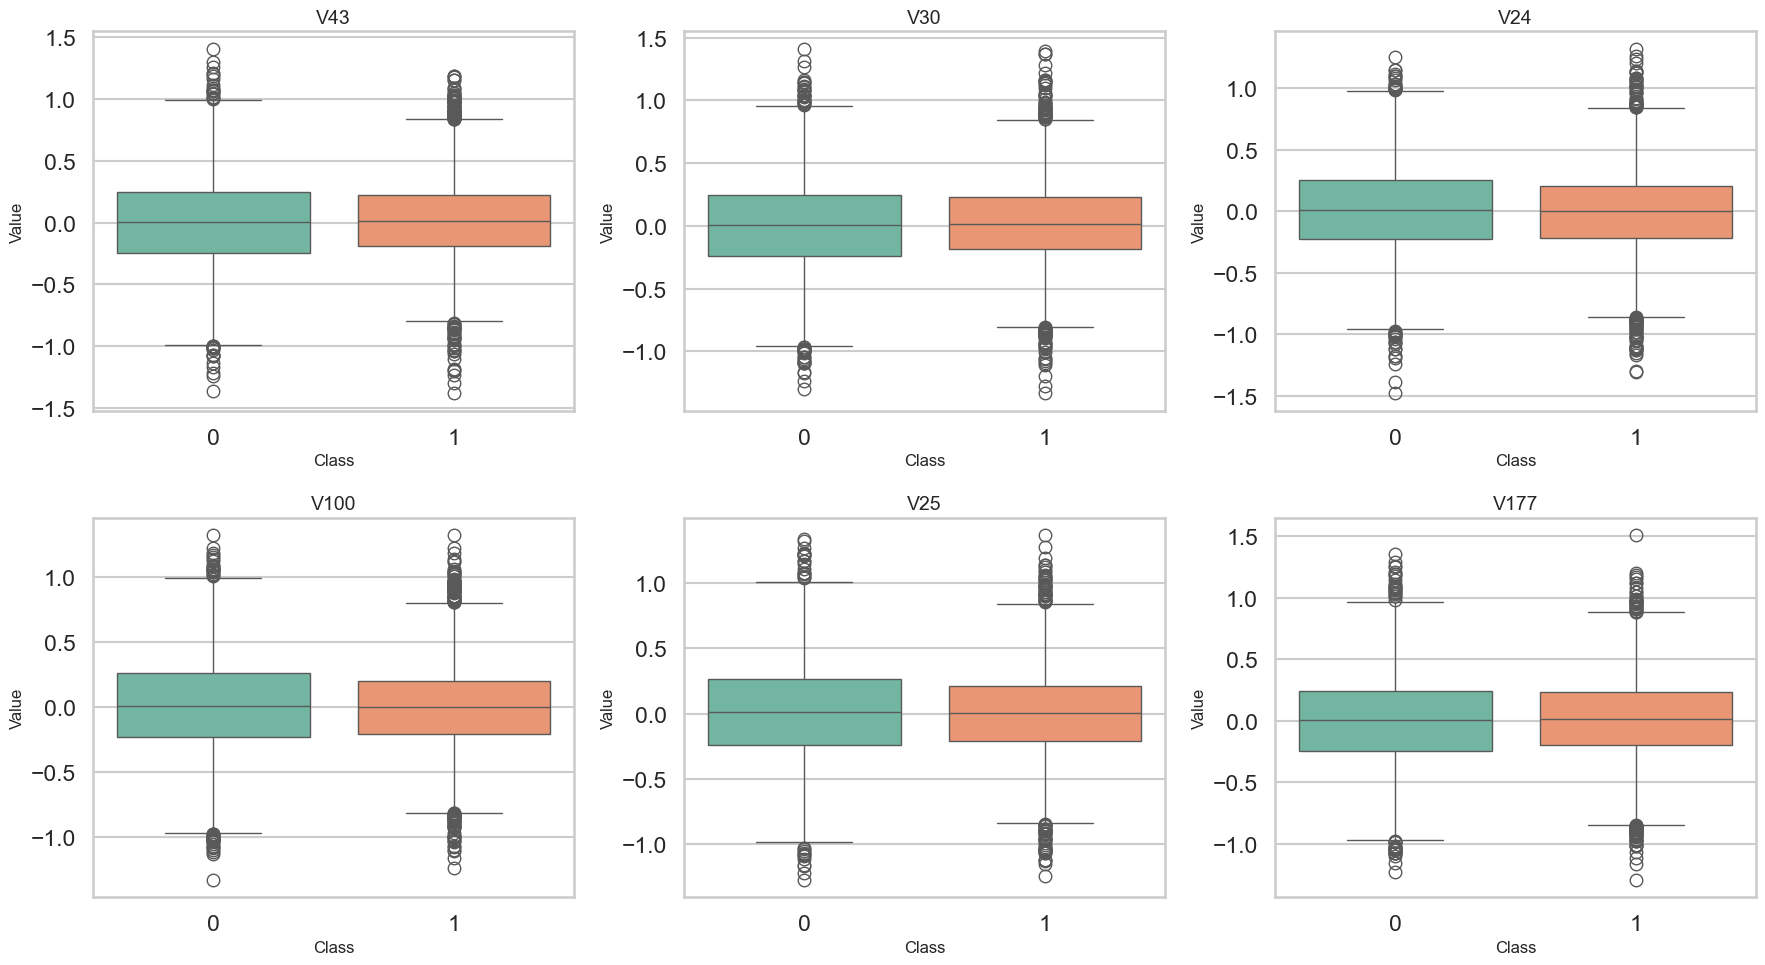

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/top_feature_boxplots.png


In [9]:
top_boxplot_features = top_gap_features.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for axis, feature in zip(axes, top_boxplot_features):
    sns.boxplot(data=train_df, x="class", y=feature, ax=axis, palette="Set2")
    axis.set_title(feature)
    axis.set_xlabel("Class")
    axis.set_ylabel("Value")

for axis in axes[len(top_boxplot_features):]:
    axis.axis("off")

boxplot_path = save_current_figure("top_feature_boxplots.png")
plt.show()

print(f"Saved figure: {boxplot_path}")

## 9. Explore the geometry of the dataset with PCA

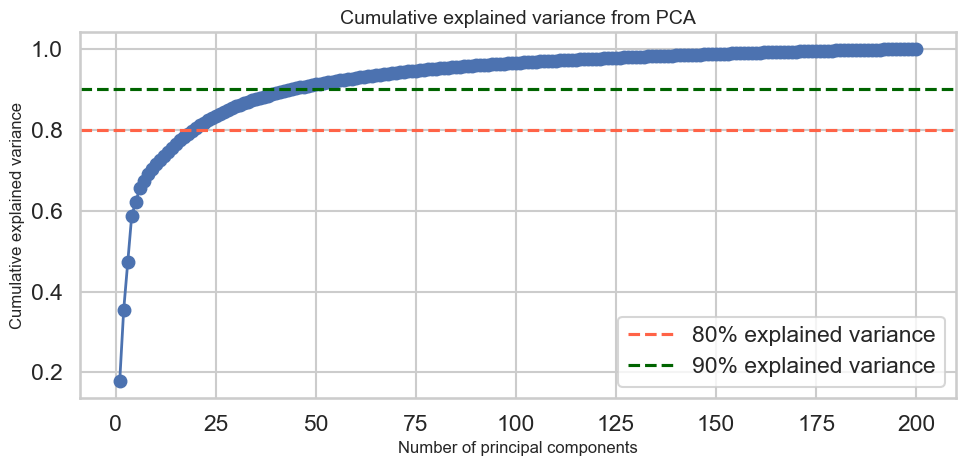

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/pca_cumulative_variance.png
Components needed for 80% variance: 20
Components needed for 90% variance: 44


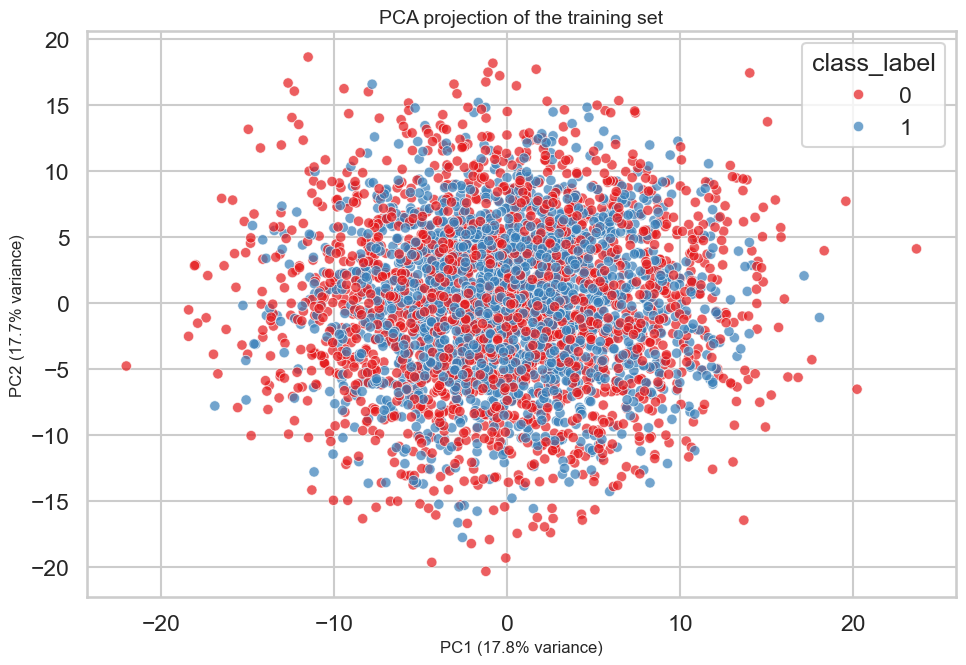

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/pca_scatter.png


In [10]:
scaler_for_pca = StandardScaler()
X_scaled_full = scaler_for_pca.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled_full)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    linewidth=2,
)
plt.axhline(0.80, color="tomato", linestyle="--", label="80% explained variance")
plt.axhline(0.90, color="darkgreen", linestyle="--", label="90% explained variance")
plt.title("Cumulative explained variance from PCA")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.legend()
variance_path = save_current_figure("pca_cumulative_variance.png")
plt.show()

print(f"Saved figure: {variance_path}")
print("Components needed for 80% variance:", int(np.argmax(cumulative_variance >= 0.80) + 1))
print("Components needed for 90% variance:", int(np.argmax(cumulative_variance >= 0.90) + 1))

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled_full)
pca_plot_df = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"]).assign(class_label=y.values)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_plot_df.sample(min(4000, len(pca_plot_df)), random_state=RANDOM_STATE),
    x="PC1",
    y="PC2",
    hue="class_label",
    palette="Set1",
    alpha=0.7,
    s=55,
)
plt.title("PCA projection of the training set")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
pca_scatter_path = save_current_figure("pca_scatter.png")
plt.show()

print(f"Saved figure: {pca_scatter_path}")

## 10. Create training and validation splits

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Training split:", X_train.shape, y_train.shape)
print("Validation split:", X_valid.shape, y_valid.shape)

Training split: (8000, 200) (8000,)
Validation split: (2000, 200) (2000,)


## 11. Train the selected model and tune the hyperparameters

In [12]:
grid_search = GridSearchCV(
    estimator=MODEL_PIPELINE,
    param_grid=PARAM_GRID,
    scoring="accuracy",
    cv=CV_FOLDS,
    n_jobs=1,
    refit=True,
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy:", round(grid_search.best_score_, 4))

cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

display(cv_results.loc[:, ["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(10))
cv_results.to_csv(output_dir / "cv_results.csv", index=False)

Best parameters:
{'model__C': 1.0, 'model__solver': 'lbfgs'}

Best cross-validation accuracy: 0.5624


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.562375,0.009854,"{'model__C': 1.0, 'model__solver': 'lbfgs'}"
1,1,0.562375,0.009980,"{'model__C': 10.0, 'model__solver': 'lbfgs'}"
2,3,0.560375,0.008419,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"
3,4,0.551625,0.010801,"{'model__C': 0.01, 'model__solver': 'lbfgs'}"


## 12. Visualize the tuning behavior for this model

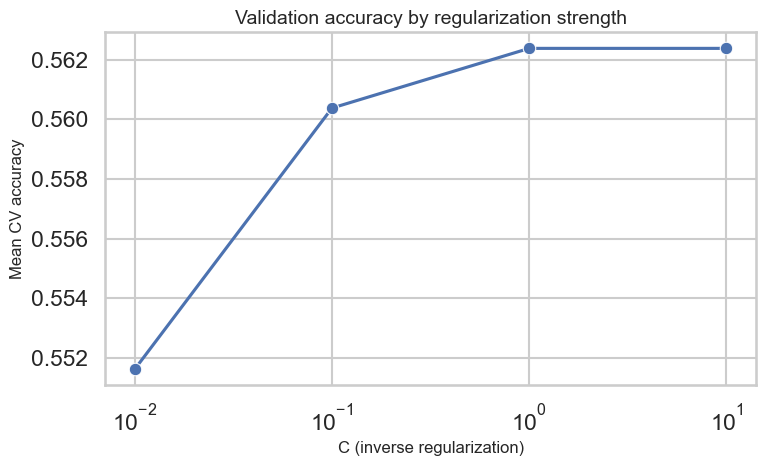

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/logreg_c_curve.png


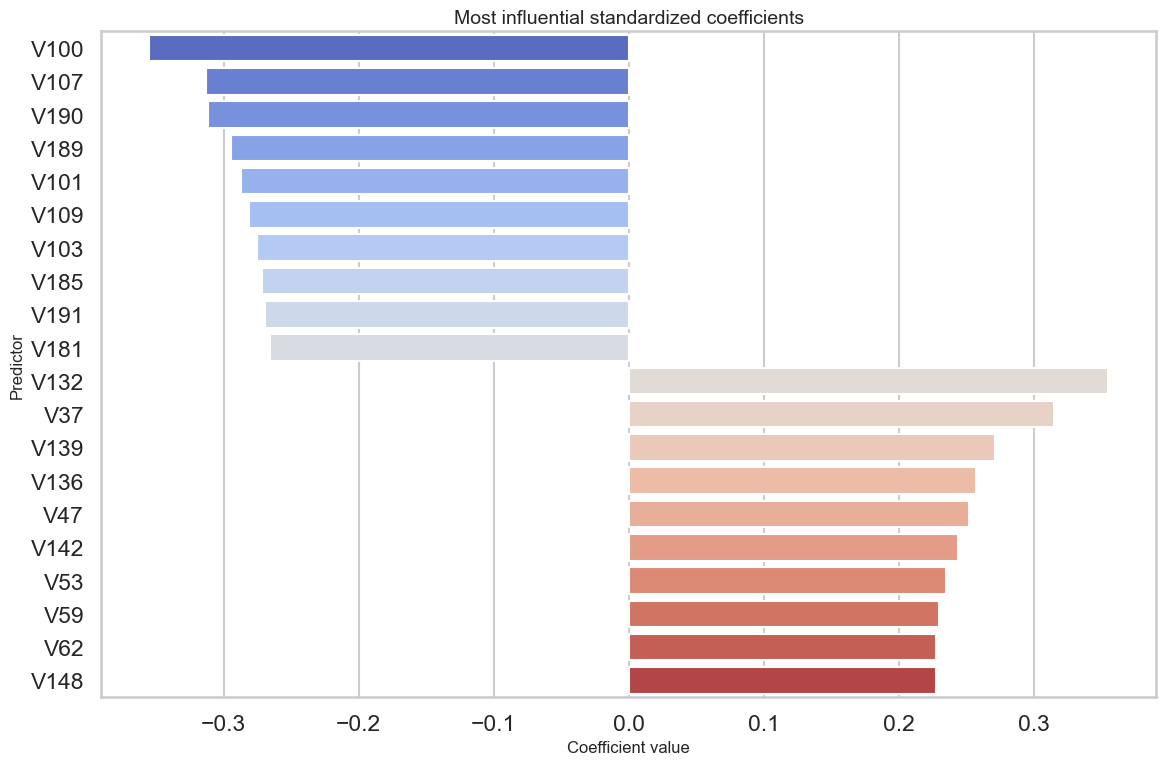

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/logreg_top_coefficients.png


In [13]:
log_results = cv_results.copy()
log_results["C"] = log_results["param_model__C"].astype(float)

plt.figure(figsize=(8, 5))
sns.lineplot(data=log_results, x="C", y="mean_test_score", marker="o")
plt.xscale("log")
plt.title("Validation accuracy by regularization strength")
plt.xlabel("C (inverse regularization)")
plt.ylabel("Mean CV accuracy")
c_path = save_current_figure("logreg_c_curve.png")
plt.show()

print(f"Saved figure: {c_path}")

best_logreg = grid_search.best_estimator_
coefficients = pd.Series(
    best_logreg.named_steps["model"].coef_.ravel(),
    index=X.columns,
)
coefficient_plot = pd.concat(
    [
        coefficients.sort_values().head(10),
        coefficients.sort_values(ascending=False).head(10),
    ]
)

plt.figure(figsize=(12, 8))
sns.barplot(x=coefficient_plot.values, y=coefficient_plot.index, palette="coolwarm")
plt.title("Most influential standardized coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Predictor")
coef_path = save_current_figure("logreg_top_coefficients.png")
plt.show()

print(f"Saved figure: {coef_path}")

## 13. Evaluate the best model on the validation split

Validation accuracy: 0.569
Confusion matrix:
[[551 449]
 [413 587]]


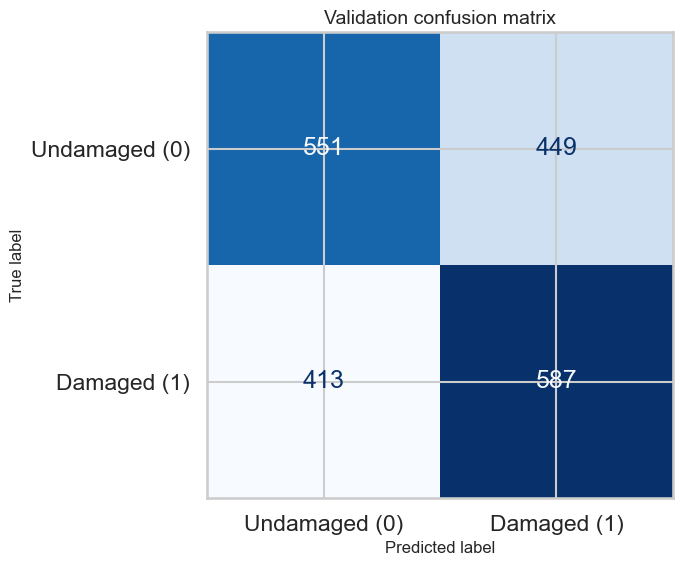

Saved figure: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/validation_confusion_matrix.png


In [14]:
valid_predictions = grid_search.predict(X_valid)
validation_report = evaluate_predictions(y_valid, valid_predictions)
validation_accuracy = validation_report["accuracy"]

print("Validation accuracy:", round(validation_accuracy, 4))
print("Confusion matrix:")
print(np.array(validation_report["confusion_matrix"]))

disp = ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    display_labels=["Undamaged (0)", "Damaged (1)"],
    cmap="Blues",
    colorbar=False,
)
disp.ax_.set_title("Validation confusion matrix")
confusion_path = save_current_figure("validation_confusion_matrix.png")
plt.show()

print(f"Saved figure: {confusion_path}")

## Interpretation

Logistic regression provides a linear decision boundary.
It is easy to interpret because the sign and magnitude of the coefficients indicate how each standardized predictor moves the decision toward class 0 or class 1.

## 14. Refit the best configuration on the full training set and generate submission

In [15]:
final_model = grid_search.best_estimator_
final_model.fit(X, y)
test_predictions = final_model.predict(X_test_kaggle)

submission_df = pd.DataFrame(
    {
        "id": test_df["id"],
        "class": test_predictions.astype(int),
    }
)

submission_path = submission_dir / f"{NOTEBOOK_SLUG}_submission.csv"
submission_df.to_csv(submission_path, index=False)
submission_df.head()

print(f"Submission saved to: {submission_path}")

Submission saved to: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/submissions/challenge_02_logistic_regression_submission.csv


## 15. Save a compact experiment summary

In [16]:
summary_payload = {
    "model_name": MODEL_NAME,
    "validation_accuracy": validation_accuracy,
    "best_cv_accuracy": float(grid_search.best_score_),
    "best_params": grid_search.best_params_,
    "output_dir": str(output_dir),
    "submission_path": str(submission_path),
}

summary_path = output_dir / "summary.json"
summary_path.write_text(json.dumps(summary_payload, indent=2))

print("Summary saved to:", summary_path)
summary_payload

Summary saved to: /Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression/summary.json


{'model_name': 'Logistic regression',
 'validation_accuracy': 0.569,
 'best_cv_accuracy': 0.5623750000000001,
 'best_params': {'model__C': 1.0, 'model__solver': 'lbfgs'},
 'output_dir': '/Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/output/challenge_02_logistic_regression',
 'submission_path': '/Users/williamfrankmonroymamani/Documents/mem/stadistics/mem-estadistics/challenge/submissions/challenge_02_logistic_regression_submission.csv'}